### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [29]:
data = pd.read_csv('data/coupons.csv')

In [30]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

In [31]:
# first, check the missing values of the dataset 
data.notnull().sum()

destination             12684
passanger               12684
weather                 12684
temperature             12684
time                    12684
coupon                  12684
expiration              12684
gender                  12684
age                     12684
maritalStatus           12684
has_children            12684
education               12684
occupation              12684
income                  12684
car                       108
Bar                     12577
CoffeeHouse             12467
CarryAway               12533
RestaurantLessThan20    12554
Restaurant20To50        12495
toCoupon_GEQ5min        12684
toCoupon_GEQ15min       12684
toCoupon_GEQ25min       12684
direction_same          12684
direction_opp           12684
Y                       12684
dtype: int64

In [32]:
data.nunique()

destination              3
passanger                4
weather                  3
temperature              3
time                     5
coupon                   5
expiration               2
gender                   2
age                      8
maritalStatus            5
has_children             2
education                6
occupation              25
income                   9
car                      5
Bar                      5
CoffeeHouse              5
CarryAway                5
RestaurantLessThan20     5
Restaurant20To50         5
toCoupon_GEQ5min         1
toCoupon_GEQ15min        2
toCoupon_GEQ25min        2
direction_same           2
direction_opp            2
Y                        2
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [33]:
# The car column has too many missiong values (only 108 rows have values out of 12684 rows)
# It's useless for our analysis, so we drop it
data = data.drop(columns=['car'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

In [34]:
# Some other columns have missing values as well, let's check them
data['Bar'].value_counts(dropna=False)


Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

In [35]:
# The 'Bar' column is currently stored as strings. To make it more useful for our analysis, 
# Let's create a new numeric column 'BarNo' to represent the the upper bound of bar visits.
# Technically 'less1' and 'never' means the same, but I will treat 'never' as 0 and 'less1' as 1, 
# which is a reasonable assumption to aovid losing information. 
# We will treat missing value as -1. 
data['BarNo'] = data['Bar'].map({
    'never': 0,
    'less1': 1,
    '1~3': 3,
    '4~8': 8,
    'gt8': 9 
}).fillna(-1)



In [36]:
# Do the same for 'CoffeeHouse' column
data['Bar'].value_counts(dropna=False)
data['CoffeeHouseNo'] = data['CoffeeHouse'].map({
    'never': 0,
    'less1': 1,
    '1~3': 3,
    '4~8': 8,
    'gt8': 9 
}).fillna(-1)

In [37]:
# Do the same for 'CarryAway' column
data['CarryAway'].value_counts(dropna=False)
data['CarryAwayNo'] = data['CarryAway'].map({
    'never': 0,
    'less1': 1,
    '1~3': 3,
    '4~8': 8,
    'gt8': 9 
}).fillna(-1)

In [38]:
# Do the same for 'RestaurantLessThan20' column
data['RestaurantLessThan20'].value_counts(dropna=False)
data['RestaurantLessThan20No'] = data['RestaurantLessThan20'].map({
    'never': 0,
    'less1': 1,
    '1~3': 3,
    '4~8': 8,
    'gt8': 9 
}).fillna(-1)

In [39]:
# Do the same for 'Restaurant20To50' column
data['Restaurant20To50'].value_counts(dropna=False)
data['Restaurant20To50No'] = data['Restaurant20To50'].map({
    'never': 0,
    'less1': 1,
    '1~3': 3,
    '4~8': 8,
    'gt8': 9 
}).fillna(-1)

In [40]:
# Income column doesn't have missing values, but it's string type. 
# So we convert it to numerical values as well for better analysis. 
# We create two columns 'IncomeLow' and 'IncomeHigh' to store the lower and upper bound of income. 
# 'Less than $12,500': IncomeLow = 0, IncomeHigh = 12500
# '$12,500 - $24,999': IncomeLow = 12500, IncomeHigh = 24999
# '$25,000 - $49,999': IncomeLow = 25000, IncomeHigh = 49999
# '$50,000 - $74,999': IncomeLow = 50000, IncomeHigh = 74999
# '$75,000 - $99,999': IncomeLow = 75000, IncomeHigh = 99999
# '$100,000 or more': IncomeLow = 100000, IncomeHigh = inf
data['income'].value_counts(dropna=False)
def get_lower_income(x):
    if x == 'Less than $12500':
        return 0
    elif x == '$100000 or More':
        return 100000
    else:
        # Your logic, plus .strip() to remove spaces, and int() to make it a number
        return int(x.split('-')[0].replace('$', '').replace(',', '').strip())

def get_upper_income(x):
    if x == 'Less than $12500':
        return 12499
    elif x == '$100000 or More':
        return np.inf
    else:
        return int(x.split('-')[1].replace('$', '').replace(',', '').strip())

# Apply your functions!
data['IncomeLow'] = data['income'].apply(get_lower_income)
data['IncomeHigh'] = data['income'].apply(get_upper_income)
data[['income', 'IncomeLow', 'IncomeHigh']].sample(20)


,income,IncomeLow,IncomeHigh
10030,$25000 - $37499,25000,37499.0
10366,$62500 - $74999,62500,74999.0
3261,$25000 - $37499,25000,37499.0
5154,$100000 or More,100000,inf
2496,$100000 or More,100000,inf
3949,$25000 - $37499,25000,37499.0
770,$25000 - $37499,25000,37499.0
7470,$50000 - $62499,50000,62499.0
1986,$50000 - $62499,50000,62499.0
5187,$12500 - $24999,12500,24999.0


In [41]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,direction_same,direction_opp,Y,BarNo,CoffeeHouseNo,CarryAwayNo,RestaurantLessThan20No,Restaurant20To50No,IncomeLow,IncomeHigh
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,0,1,1,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,0,1,1,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0


4. What proportion of the total observations chose to accept the coupon?



In [42]:
counts = data['Y'].value_counts()
print("Counts:\n", counts)
proportions = data['Y'].value_counts(normalize=True)
print("\nProportions:\n", proportions)

# About 56.84% of the total observations chose to accept the coupon.

Counts:
 Y
1    7210
0    5474
Name: count, dtype: int64

Proportions:
 Y
1    0.568433
0    0.431567
Name: proportion, dtype: float64


5. Use a bar plot to visualize the `coupon` column.

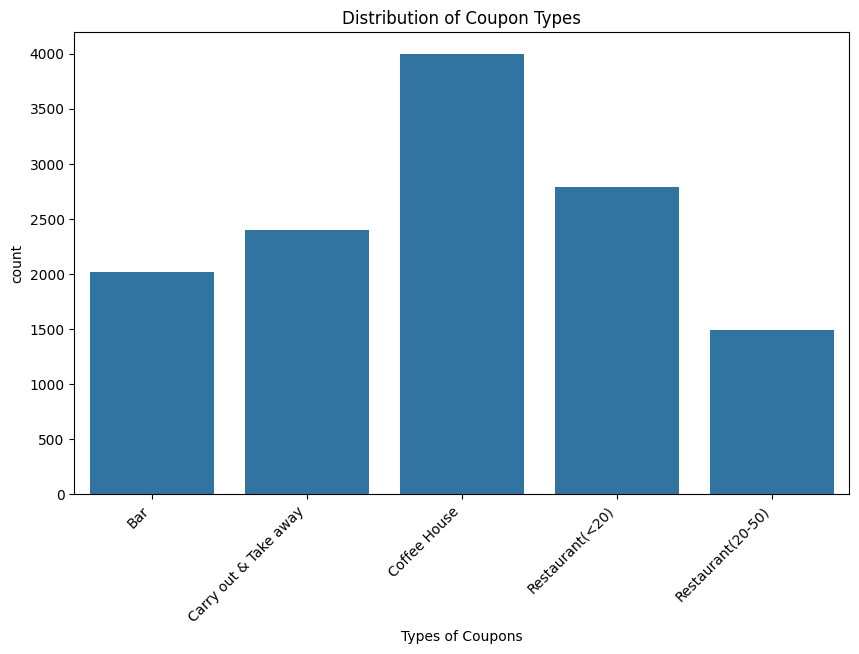

In [43]:
# Let's define the order we want to show the types of coupons 
custom_order = [
    'Bar', 
    'Carry out & Take away', 
    'Coffee House', 
    'Restaurant(<20)', 
    'Restaurant(20-50)'
]

# Create the plot
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='coupon', order=custom_order)
plt.xlabel("Types of Coupons")
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Coupon Types")
plt.show()

6. Use a histogram to visualize the temperature column.

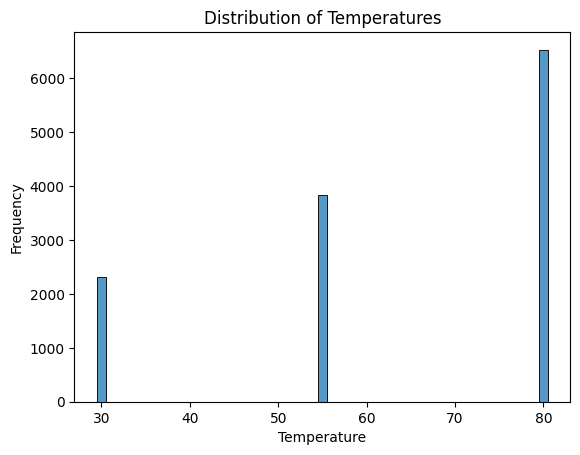

In [44]:
sns.histplot(data=data, x='temperature', discrete=True)
plt.title("Distribution of Temperatures")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

# The plot shows a heavy skew toward warmer weather. The highest volume of data points occurs at 80 degrees.
# This indicates that the dataset is not evenly distributed across seasons. 
# The reasion behind might be drivers are more willing to take the survey when the weather is warmer.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [45]:
bar_coupons = data[data['coupon'] == 'Bar']
bar_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,direction_same,direction_opp,Y,BarNo,CoffeeHouseNo,CarryAwayNo,RestaurantLessThan20No,Restaurant20To50No,IncomeLow,IncomeHigh
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,1,0,1,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,0,1,1,0.0,1.0,8.0,8.0,1.0,62500,74999.0
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,1,0,1,0.0,1.0,8.0,8.0,1.0,62500,74999.0


2. What proportion of bar coupons were accepted?


In [46]:
bar_coupons_proportions = bar_coupons['Y'].value_counts(normalize=True)
bar_coupons_proportions

# Alternative way: bar_coupons['Y'].mean(). 
# This works because there are only 0 and 1 in the 'Y' column.
# The mean is equivalent to the proportion of 1s.

# Result: about 41.00% of bar coupons were accepted.

Y
0    0.589985
1    0.410015
Name: proportion, dtype: float64

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [47]:
# Calculate the acceptance rate of those who went to a bar 3 or fewer times a month 
# Missing values will be ignored.
bar_coupons_3_or_fewer = bar_coupons.query('BarNo <= 3 and BarNo >= 0')
bar_coupons_3_or_fewer_acceptance_rate = bar_coupons_3_or_fewer['Y'].mean()
bar_coupons_3_or_fewer_acceptance_rate


np.float64(0.37061769616026713)

In [48]:
# Calculate the acceptance rate of those who went to a bar more than 3 times a month 
bar_coupons_more_than_3 = bar_coupons.query('BarNo > 3')
bar_coupons_more_than_3_acceptance_rate = bar_coupons_more_than_3['Y'].mean()
bar_coupons_more_than_3_acceptance_rate

np.float64(0.7688442211055276)

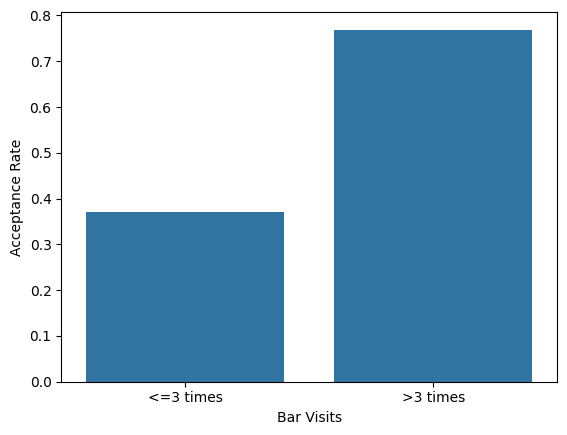

In [49]:
# Now we compare them in a plot
bar_coupons_acceptance_rate = pd.DataFrame({
    'Bar Visits': ['<=3 times', '>3 times'],
    'Acceptance Rate': [bar_coupons_3_or_fewer_acceptance_rate, bar_coupons_more_than_3_acceptance_rate]
})
sns.barplot(x='Bar Visits', y='Acceptance Rate', data=bar_coupons_acceptance_rate)
plt.show()
# We can see that the acceptance rate is significantly higher for those who went to a bar more than 3 times a month.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


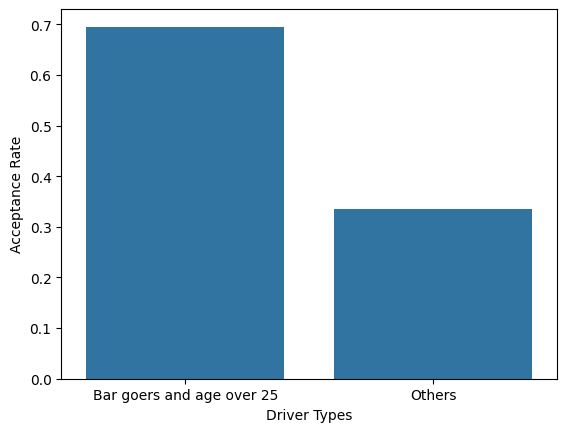

In [50]:
# Notice that age column is string. 
# We can convert them to numeric first to facilitate the filtering, but we also can do the following:
bar_coupons_true_adults = bar_coupons.query('BarNo > 1 and age != "21" and age != "below21"')
bar_coupons_true_adults_acceptance_rate = bar_coupons_true_adults['Y'].mean()
bar_coupons_others = bar_coupons.drop(bar_coupons_true_adults.index)
bar_coupons_others_acceptance_rate = bar_coupons_others['Y'].mean()

bar_coupons_acceptance_rate_2 = pd.DataFrame({
    'Driver Types': ['Bar goers and age over 25', 'Others'],
    'Acceptance Rate': [bar_coupons_true_adults_acceptance_rate, bar_coupons_others_acceptance_rate]
})
sns.barplot(x='Driver Types', y='Acceptance Rate', data=bar_coupons_acceptance_rate_2)
plt.show()
# The plot shows a big difference in acceptance rate between the two groups.
# The acceptance rate of bar goers and age over 25 is much higher than the other group.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


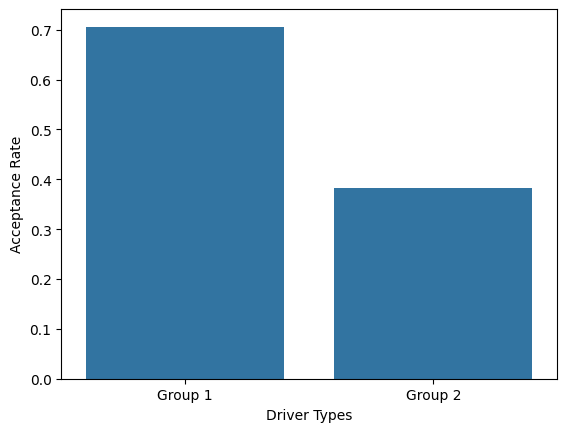

In [51]:
bar_coupons_group_1 = bar_coupons.query('BarNo > 1 and passanger != "Alone" and passanger != "Kid(s)" and occupation != "Unemployed" and occupation != "Farming Fishing & Forestry"')
bar_coupons_group_1_acceptance_rate = bar_coupons_group_1['Y'].mean()
bar_coupons_group_2 = bar_coupons.drop(bar_coupons_group_1.index)
bar_coupons_group_2_acceptance_rate = bar_coupons_group_2['Y'].mean()

bar_coupons_acceptance_rate_3 = pd.DataFrame({
    'Driver Types': ['Group 1', 'Group 2'],
    'Acceptance Rate': [bar_coupons_group_1_acceptance_rate, bar_coupons_group_2_acceptance_rate]
})
sns.barplot(x='Driver Types', y='Acceptance Rate', data=bar_coupons_acceptance_rate_3)
plt.show()

# This also shows a great different between the two groups

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



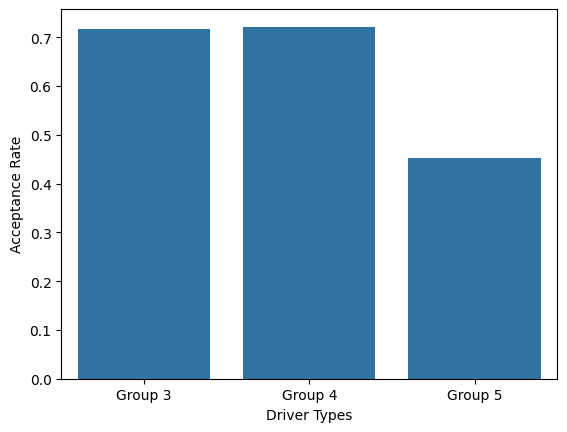

In [52]:

bar_coupons_group_3 = bar_coupons.query('BarNo > 1 and passanger != "Alone" and passanger != "Kid(s)" and maritalStatus != "Widowed"')
bar_coupons_group_3_acceptance_rate = bar_coupons_group_3['Y'].mean()

bar_coupons_group_4 = bar_coupons.query('BarNo > 1 and (age=="21" or age=="26" or age=="below21")')
bar_coupons_group_4_acceptance_rate = bar_coupons_group_4['Y'].mean()

bar_coupons_group_5 = bar_coupons.query('RestaurantLessThan20No > 3 and IncomeHigh < 50000')
bar_coupons_group_5_acceptance_rate = bar_coupons_group_5['Y'].mean()

bar_coupons_acceptance_rate_4 = pd.DataFrame({
    'Driver Types': ['Group 3', 'Group 4', 'Group 5'],
    'Acceptance Rate': [bar_coupons_group_3_acceptance_rate, bar_coupons_group_4_acceptance_rate, bar_coupons_group_5_acceptance_rate]
})
sns.barplot(x='Driver Types', y='Acceptance Rate', data=bar_coupons_acceptance_rate_4)
plt.show()


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [53]:
# 1. Bar visit frequency is a very good indicator of whether the driver will accept the bar coupon or not.
#    Drivers who visit bars more than 3 times a month are roughly twice as likely to accept the coupon than those who visit bars less than 3 times a month.
# 2. Income has a small effect on whether the driver will accept the coupon or not.
#    Drivers with lower income are less likely to accept the coupon.
#
# Overall, the data suggests that the ideal target for a Bar coupon is: 
#   - over 25
#   - already visits bars regularly (at least once a month, but ideally more than 3 times)
#   - currently driving with adult passengers (friends or a partner)
#   - employed and has an income more than 50k

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [ ]:
# Let's analyze the coffee house coupons. 
# I am curious about how to following 4 factors affect the coupon acceptance rate.
# - coffee house visit frequency
# - coupon expiration time 
# - time of the day
# - direction (same or opposite)

In [56]:
# First let's filter out all coffee house coupons
coffee_coupons = data[data['coupon'] == 'Coffee House']
coffee_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,direction_same,direction_opp,Y,BarNo,CoffeeHouseNo,CarryAwayNo,RestaurantLessThan20No,Restaurant20To50No,IncomeLow,IncomeHigh
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,0,1,1,0.0,0.0,-1.0,8.0,3.0,37500,49999.0
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,0,1,0,0.0,0.0,-1.0,8.0,3.0,37500,49999.0


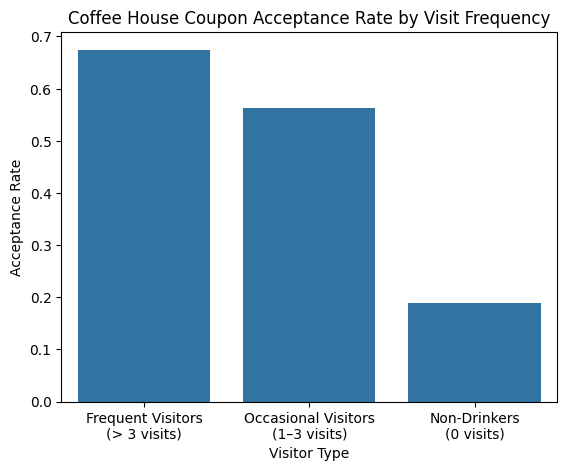

In [ ]:
# coffee house visit frequency
coffee_coupons_freq_visitors = coffee_coupons.query("CoffeeHouseNo > 3")
coffee_coupons_freq_visitors_acceptance_rate = coffee_coupons_freq_visitors["Y"].mean()

coffee_coupons_non_freq_visitors = coffee_coupons.query("CoffeeHouseNo >= 1 and CoffeeHouseNo <= 3")
coffee_coupons_non_freq_visitors_acceptance_rate = coffee_coupons_non_freq_visitors["Y"].mean()

coffee_coupons_non_drinker = coffee_coupons.query("CoffeeHouseNo == 0")
coffee_coupons_non_drinker_acceptance_rate = coffee_coupons_non_drinker["Y"].mean()

coffee_coupons_acceptance_by_freq = pd.DataFrame({
    'Visitor Type': ['Frequent Visitors\n(> 3 visits)', 'Occasional Visitors\n(1–3 visits)', 'Non-Drinkers\n(0 visits)'],
    'Acceptance Rate': [
        coffee_coupons_freq_visitors_acceptance_rate,
        coffee_coupons_non_freq_visitors_acceptance_rate,
        coffee_coupons_non_drinker_acceptance_rate
    ]
})
sns.barplot(x='Visitor Type', y='Acceptance Rate', data=coffee_coupons_acceptance_by_freq)
plt.title('Coffee House Coupon Acceptance Rate by Visit Frequency')
plt.show()

# It's obvious that drivers who visit coffee houses more frequently are more likely to accept the coupon.
# What's surprising is even non-drinkers show roughly 20% of chance to accept the coupon.

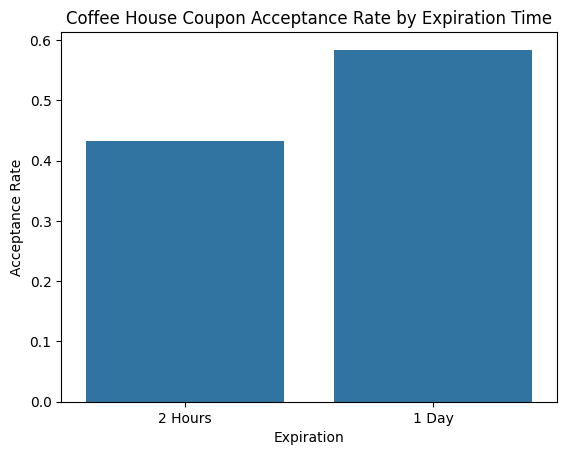

In [70]:
# coupon expiration time 
coffee_coupons_expire_2h = coffee_coupons.query("expiration == '2h'")
coffee_coupons_expire_2h_acceptance_rate = coffee_coupons_expire_2h["Y"].mean()

coffee_coupons_expire_1d = coffee_coupons.query("expiration == '1d'")
coffee_coupons_expire_1d_acceptance_rate = coffee_coupons_expire_1d["Y"].mean()


coffee_coupons_acceptance_by_expiration = pd.DataFrame({
    'Expiration': ['2 Hours', '1 Day'],
    'Acceptance Rate': [coffee_coupons_expire_2h_acceptance_rate, coffee_coupons_expire_1d_acceptance_rate]
})
sns.barplot(x='Expiration', y='Acceptance Rate', data=coffee_coupons_acceptance_by_expiration)
plt.title('Coffee House Coupon Acceptance Rate by Expiration Time')
plt.show()

# Drivers are more likely to accept coupons that expire in 1 day than in 2 hours.
# 2-hour window may feel too restrictive.

   time         Y
0  10AM  0.640712
1  10PM  0.424242
2   2PM  0.547859
3   6PM  0.412626
4   7AM  0.445783


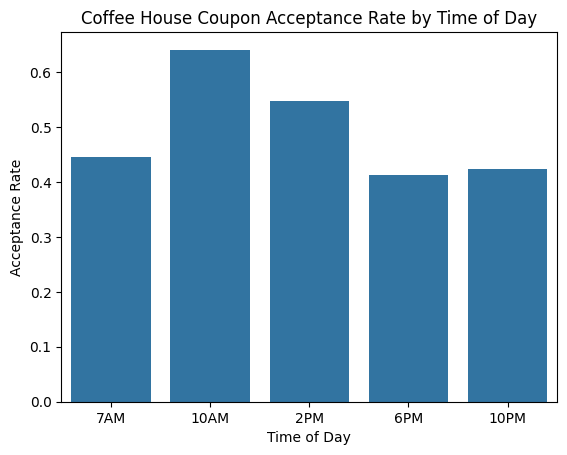

In [ ]:
# time of day 
# There are 5 different values, so we use groupby function to better organize our code
coffee_coupons_by_time = coffee_coupons.groupby('time')['Y'].mean().reset_index()
coffee_coupons_by_time.columns = ['Time of Day', 'Acceptance Rate']
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
coffee_coupons_by_time['Time of Day'] = pd.Categorical(coffee_coupons_by_time['Time of Day'], categories=time_order, ordered=True)
coffee_coupons_by_time = coffee_coupons_by_time.sort_values('Time of Day')
sns.barplot(x='Time of Day', y='Acceptance Rate', data=coffee_coupons_by_time)
plt.title('Coffee House Coupon Acceptance Rate by Time of Day')
plt.show()

# The plot shows that drivers are likely to accept the coupon at late morning or early afternoon. This is expected.

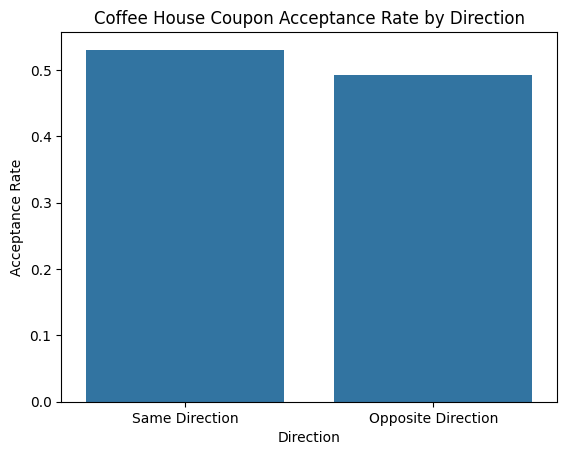

In [ ]:
# direction
coffee_coupons_same_dir = coffee_coupons.query("direction_same == 1")
coffee_coupons_same_dir_acceptance_rate = coffee_coupons_same_dir["Y"].mean()

coffee_coupons_opp_dir = coffee_coupons.query("direction_opp == 1")
coffee_coupons_opp_dir_acceptance_rate = coffee_coupons_opp_dir["Y"].mean()

coffee_coupons_acceptance_by_direction = pd.DataFrame({
    'Direction': ['Same Direction', 'Opposite Direction'],
    'Acceptance Rate': [coffee_coupons_same_dir_acceptance_rate, coffee_coupons_opp_dir_acceptance_rate]
})
sns.barplot(x='Direction', y='Acceptance Rate', data=coffee_coupons_acceptance_by_direction)
plt.title('Coffee House Coupon Acceptance Rate by Direction')
plt.show()

# To our surprise, same direction coupon only wins slightly over opposite direction. 


### Coffee House Coupons Summary

- Frequent visitors (> 3 visits) are the most likely to accept. But there is still about 20% chance that non-drinkers will accept. 
- Coupons expiring in 1 day will be more likely to be accepted.
- Acceptance rate peaks around noon (late morning to early afternoon).
- Direction has very little impact — drivers are willing to detour for coffee.
